# B0 distortions

In [2]:
import torch
from cornucopia import (
    ApplyB0DistortionTransform,
    SusceptibilityToFieldmapTransform,
    RandomSusceptibilityMixtureTransform,
    HertzToVoxelShiftTransform,
    OptimalShimTransform,
    SmoothTransform,
    random as ccr
)
from cornucopia.utils.py import meshgrid_ij
import matplotlib.pyplot as plt

Let's generate a synthetic label map.
We will assign different magnetic susceptibilties to each label.

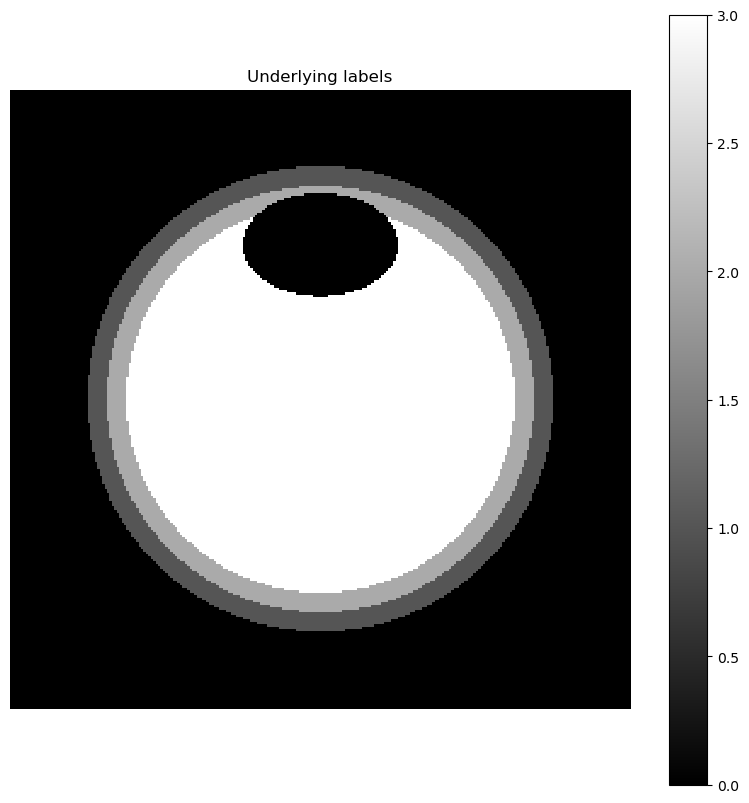

In [16]:
shape = [256] * 3
grid = torch.stack(meshgrid_ij(*[torch.arange(s).float() for s in shape]), -1)

radius = grid.clone()
radius -= (torch.as_tensor(shape).float() - 1) / 2
radius = radius.square().sum(-1).sqrt()

lab = torch.zeros_like(radius, dtype=torch.long)
lab[radius < shape[0] * 3/8] = 1
lab[radius < shape[0] * 11/32] = 2
lab[radius < shape[0] * 5/16] = 3

# insert sinus-like structure
radius = grid.clone()
radius[..., 0] -= (shape[0] - 1) / 2
radius[..., 1] -= (shape[1] - 1) / 4
radius[..., 2] -= (shape[2] - 1) / 2
radius[..., 0] *= 0.7
radius[..., 1] *= 1.5
radius = radius.square().sum(-1).sqrt()

lab[radius < shape[0] * 1/8] = 0

plt.figure(figsize=(10, 10))
plt.imshow(lab[shape[0]//2], cmap='gray', interpolation='nearest')
plt.axis('off')
plt.title('Underlying labels')
plt.colorbar()
plt.show()

Let's now generate a magnetic susceptibility maps, and compute a field map from it.

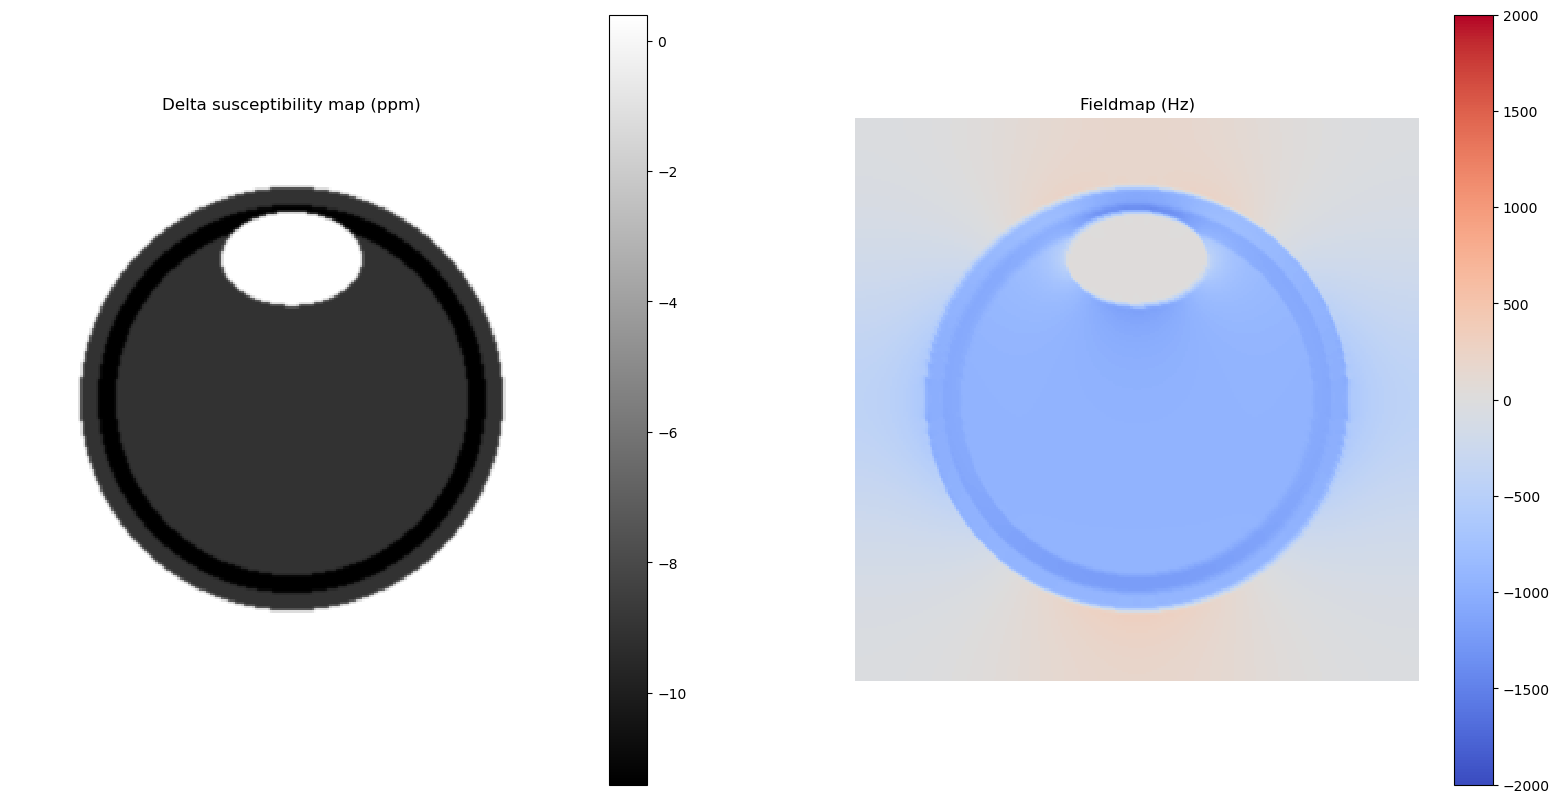

In [17]:
make_chi = RandomSusceptibilityMixtureTransform(
    label_bone=[2],
    mu_tissue=ccr.Fixed(9.5),
    mu_bone=ccr.Fixed(11.8),
    sigma_tissue=0,
    fwhm=ccr.Fixed(2),
)
chi = make_chi(lab[None])[0]

chi = SmoothTransform(fwhm=1)(chi[None])[0]

chi2hz = SusceptibilityToFieldmapTransform(axis=2, mask_air=False)
fmap = chi2hz(chi[None])[0]

plt.figure(figsize=(20, 10))
plt.subplot(1, 2, 1)
plt.imshow(chi[shape[0]//2] + 0.4, cmap='gray', interpolation='nearest')
plt.axis('off')
plt.title('Delta susceptibility map (ppm)')
plt.colorbar()
plt.subplot(1, 2, 2)
plt.imshow(fmap[shape[0]//2], cmap='coolwarm', interpolation='nearest', vmin=-2000, vmax=2000)
plt.axis('off')
plt.title('Fieldmap (Hz)')
plt.colorbar()
plt.show()

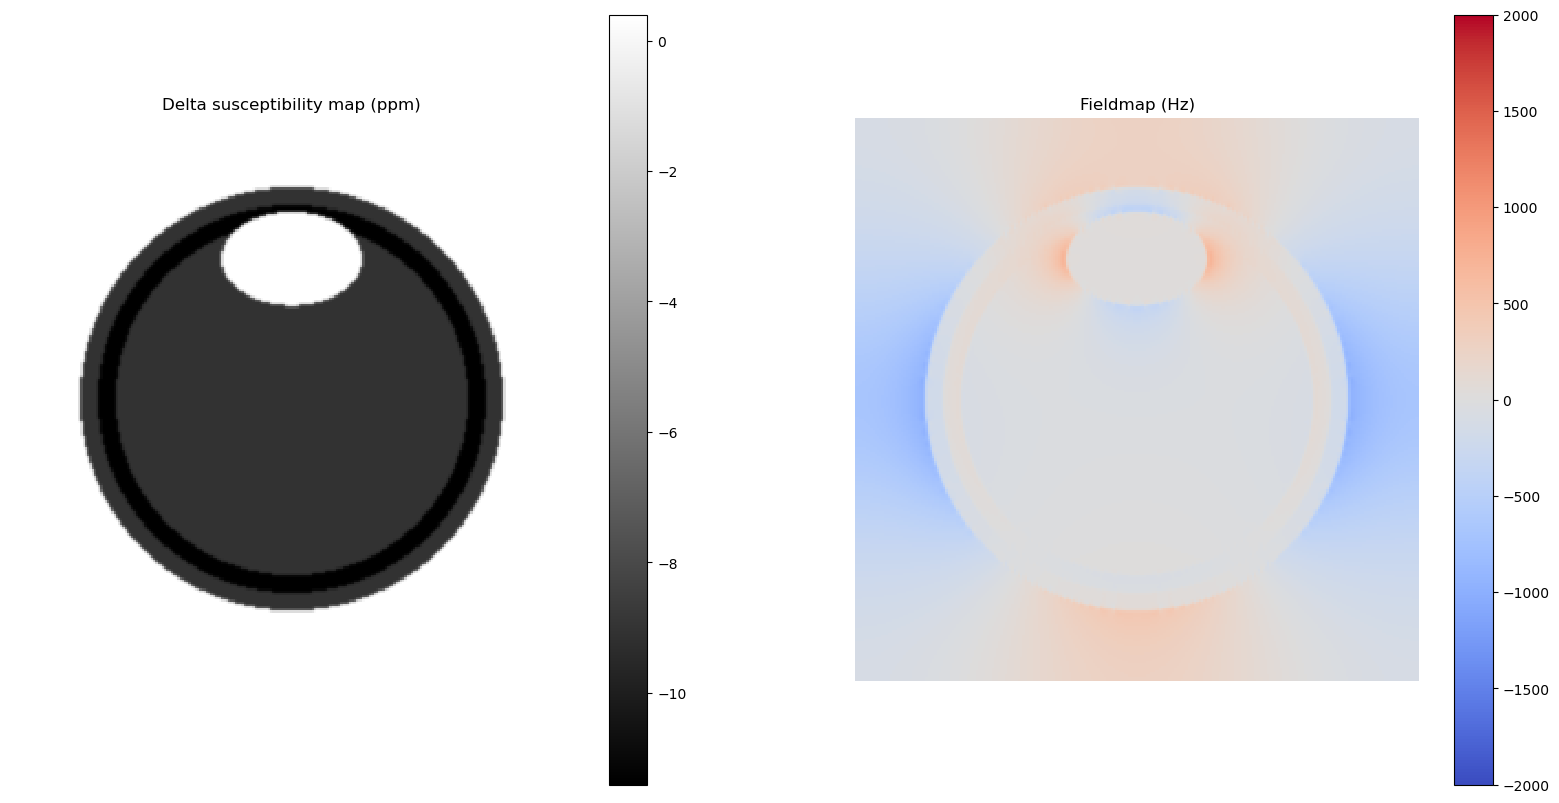

In [18]:
chi2hz = SusceptibilityToFieldmapTransform(axis=2, mask_air=False, mode="marques")
fmap_m = chi2hz(chi[None])[0]

plt.figure(figsize=(20, 10))
plt.subplot(1, 2, 1)
plt.imshow(chi[shape[0]//2] + 0.4, cmap='gray', interpolation='nearest')
plt.axis('off')
plt.title('Delta susceptibility map (ppm)')
plt.colorbar()
plt.subplot(1, 2, 2)
plt.imshow(fmap_m[shape[0]//2], cmap='coolwarm', interpolation='nearest', vmin=-2000, vmax=2000)
plt.axis('off')
plt.title('Fieldmap (Hz)')
plt.colorbar()
plt.show()

In general, we use shim gradients to remove most of the distortions.

RSS centered fmap: 52.93035888671875
RSS shimmed fmap: 52.526695251464844


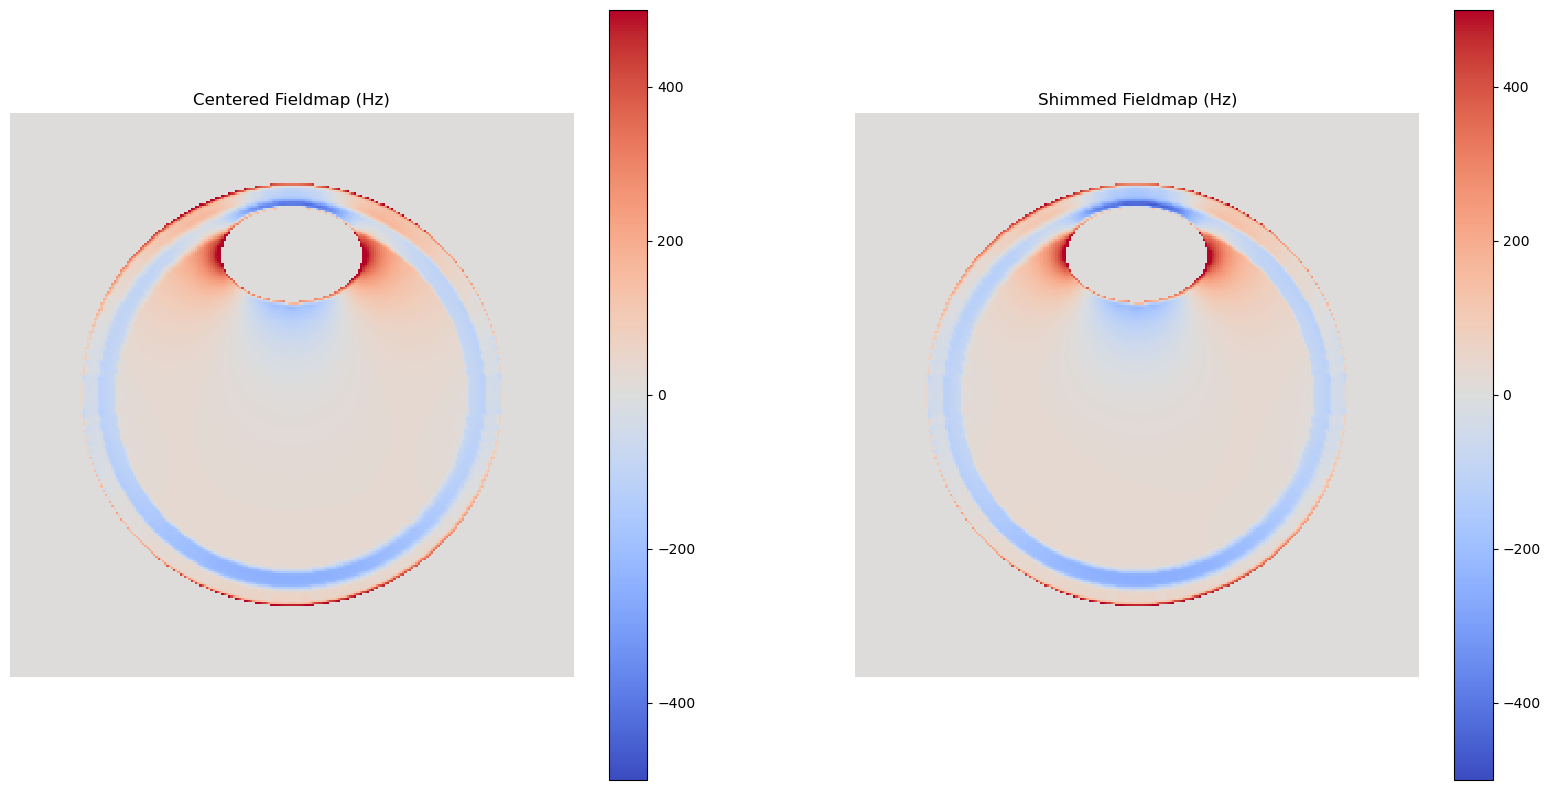

In [20]:
# simple shim (zero-th order == frequency adjust)
centered_fmap = fmap - fmap[lab != 0].mean()
centered_fmap *= (lab != 0)

print("RSS centered fmap:", (centered_fmap ** 2).mean().sqrt().item())

# optimal shim (second order)
shim = OptimalShimTransform(lam_grad=0, mask=(lab != 0))
shimed_fmap = shim(fmap[None])[0]
shimed_fmap *= (lab != 0)

print("RSS shimmed fmap:", (shimed_fmap ** 2).mean().sqrt().item())

plt.figure(figsize=(20, 10))
plt.subplot(1, 2, 1)
plt.imshow(centered_fmap[shape[0]//2], cmap='coolwarm', interpolation='nearest', vmin=-500, vmax=500)
plt.axis('off')
plt.title('Centered Fieldmap (Hz)')
plt.colorbar()
plt.subplot(1, 2, 2)
plt.imshow(shimed_fmap[shape[0]//2], cmap='coolwarm', interpolation='nearest', vmin=-500, vmax=500)
plt.axis('off')
plt.title('Shimmed Fieldmap (Hz)')
plt.colorbar()
plt.show()

RSS centered fmap: 34.38340759277344
RSS shimmed fmap: 33.12874221801758


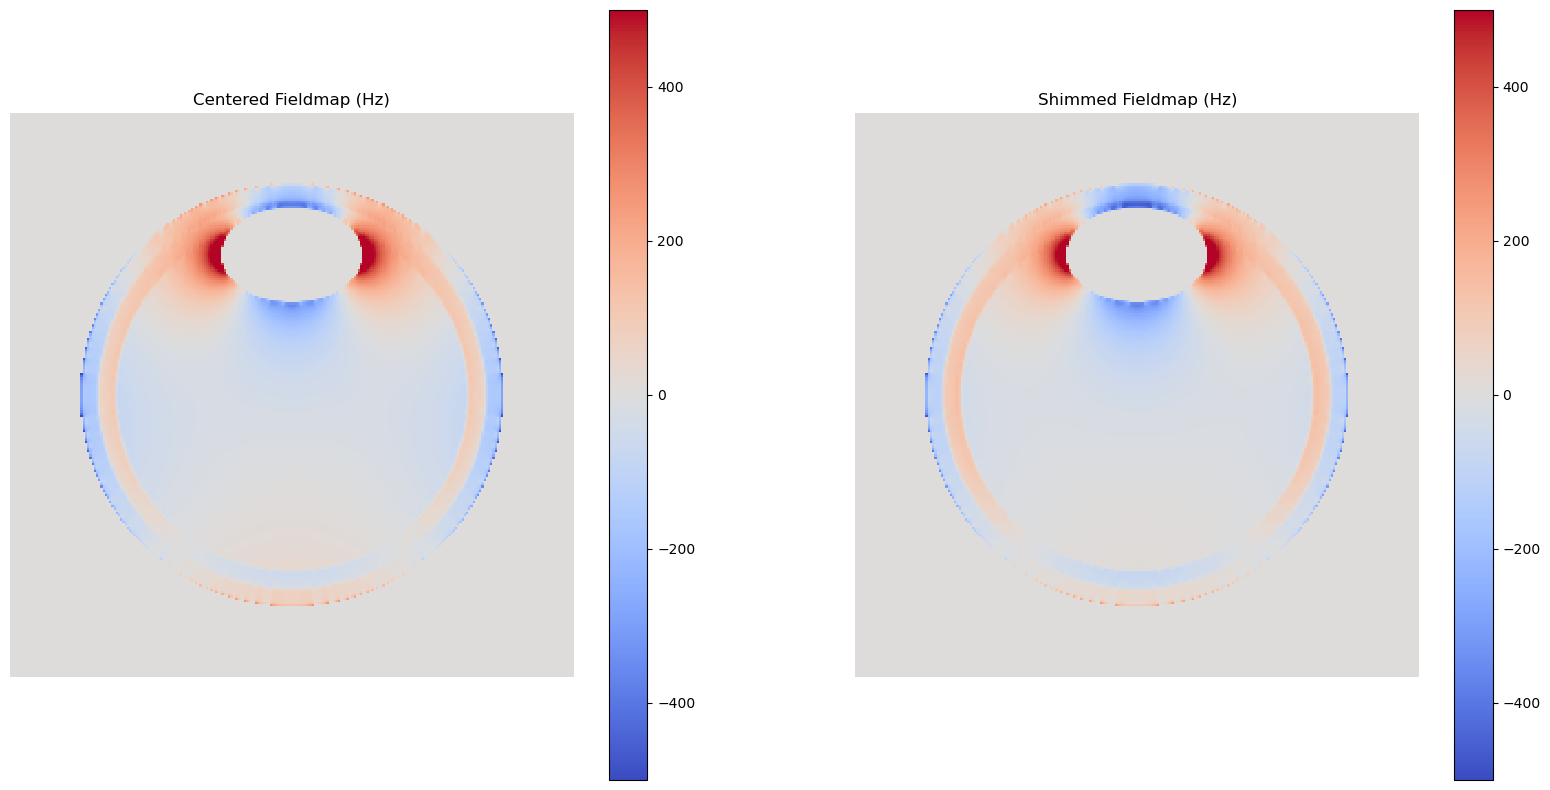

In [21]:
# simple shim (zero-th order == frequency adjust)
centered_fmap_m = fmap_m - fmap_m[lab != 0].mean()
centered_fmap_m *= (lab != 0)

print("RSS centered fmap:", (centered_fmap_m ** 2).mean().sqrt().item())

# optimal shim (second order)
shim = OptimalShimTransform(lam_grad=0, mask=(lab != 0))
shimed_fmap_m = shim(fmap_m[None])[0]
shimed_fmap_m *= (lab != 0)

print("RSS shimmed fmap:", (shimed_fmap_m ** 2).mean().sqrt().item())

plt.figure(figsize=(20, 10))
plt.subplot(1, 2, 1)
plt.imshow(centered_fmap_m[shape[0]//2], cmap='coolwarm', interpolation='nearest', vmin=-500, vmax=500)
plt.axis('off')
plt.title('Centered Fieldmap (Hz)')
plt.colorbar()
plt.subplot(1, 2, 2)
plt.imshow(shimed_fmap_m[shape[0]//2], cmap='coolwarm', interpolation='nearest', vmin=-500, vmax=500)
plt.axis('off')
plt.title('Shimmed Fieldmap (Hz)')
plt.colorbar()
plt.show()

We can now convert this field map to a voxel displacement map, and apply 
it to the original label map (which is our proxy for "anatomy")

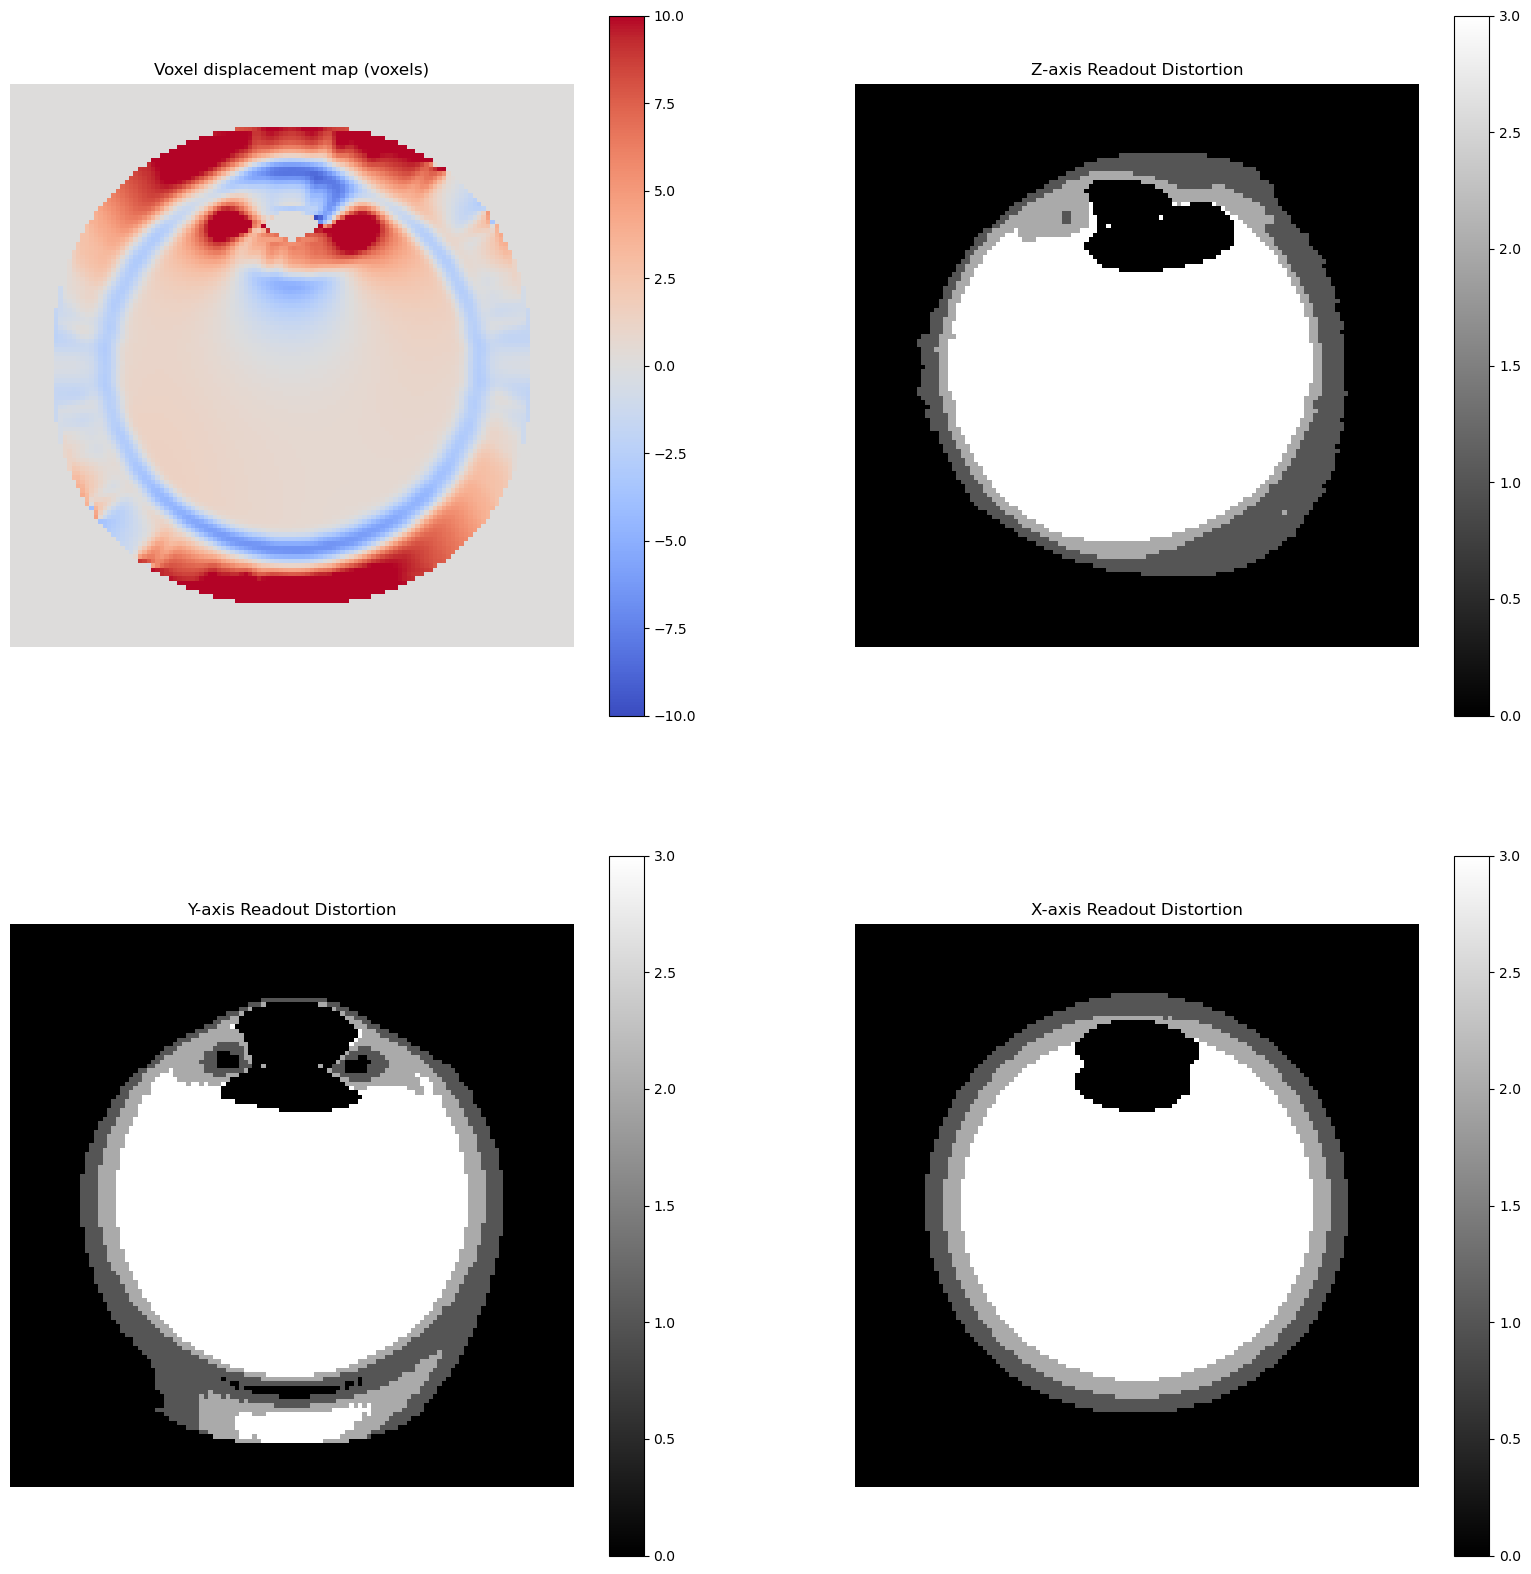

In [15]:
# smooth vdm a bit
smooth = SmoothTransform(fwhm=3)
smooth_fmap = smooth(shimed_fmap[None])[0]
smooth_mask = smooth((chi != 0).float()[None])[0]
smooth_fmap[smooth_mask > 0] /= smooth_mask[smooth_mask > 0]

# convert to voxel shifts
hz2vdm = HertzToVoxelShiftTransform()
vdm = hz2vdm(smooth_fmap[None])[0]

# apply vdm
# = push voxels to their distorted location
# = pull via the inverse vdm
ivdm = -vdm

# apply voxel displacement map
zreadout = ApplyB0DistortionTransform(vdm=ivdm[None], axis=2)
yreadout = ApplyB0DistortionTransform(vdm=ivdm[None], axis=1)
xreadout = ApplyB0DistortionTransform(vdm=ivdm[None], axis=0)

wlabz = zreadout(lab[None])[0]
wlaby = yreadout(lab[None])[0]
wlabx = xreadout(lab[None])[0]

plt.figure(figsize=(20, 20))
plt.subplot(2, 2, 1)
plt.imshow(vdm[64], cmap='coolwarm', interpolation='nearest', vmin=-10, vmax=10)
plt.axis('off')
plt.title('Voxel displacement map (voxels)')
plt.colorbar()
plt.subplot(2, 2, 2)
plt.imshow(wlabz[64], cmap='gray', interpolation='nearest')
plt.axis('off')
plt.title('Z-axis Readout Distortion')
plt.colorbar()
plt.subplot(2, 2, 3)
plt.imshow(wlaby[64], cmap='gray', interpolation='nearest')
plt.axis('off')
plt.title('Y-axis Readout Distortion')
plt.colorbar()
plt.subplot(2, 2, 4)
plt.imshow(wlabx[64], cmap='gray', interpolation='nearest')
plt.axis('off')
plt.title('X-axis Readout Distortion')
plt.colorbar()
plt.show()

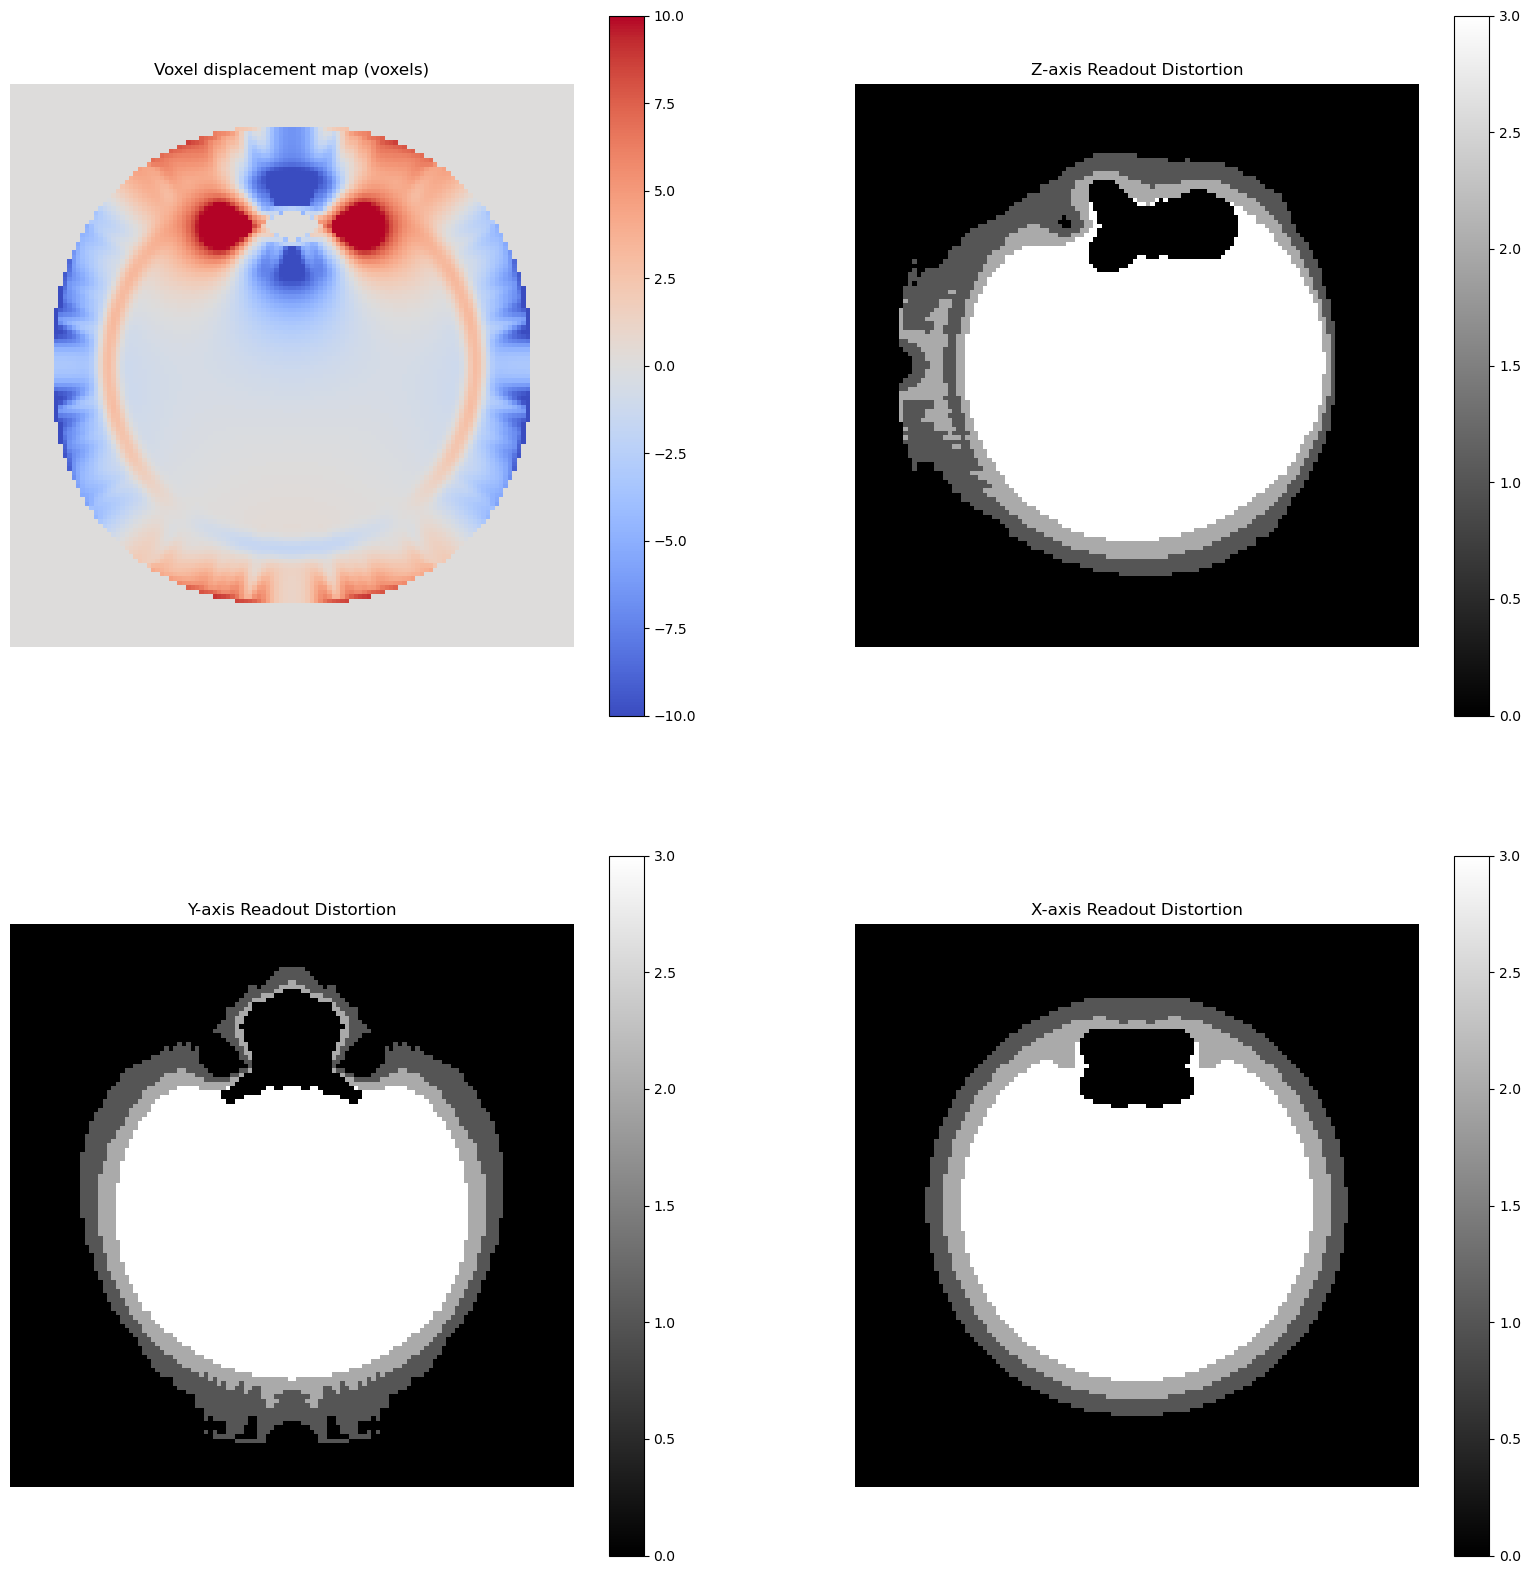

In [17]:
# smooth vdm a bit
smooth = SmoothTransform(fwhm=3)
smooth_fmap_m = smooth(shimed_fmap_m[None])[0]
smooth_mask = smooth((chi != 0).float()[None])[0]
smooth_fmap_m[smooth_mask > 0] /= smooth_mask[smooth_mask > 0]

# convert to voxel shifts
hz2vdm = HertzToVoxelShiftTransform()
vdm_m = hz2vdm(smooth_fmap_m[None])[0]

# apply vdm
# = push voxels to their distorted location
# = pull via the inverse vdm
ivdm_m = -vdm_m

# apply voxel displacement map
zreadout_m = ApplyB0DistortionTransform(vdm=ivdm_m[None], axis=2)
yreadout_m = ApplyB0DistortionTransform(vdm=ivdm_m[None], axis=1)
xreadout_m = ApplyB0DistortionTransform(vdm=ivdm_m[None], axis=0)

wlabz_m = zreadout_m(lab[None])[0]
wlaby_m = yreadout_m(lab[None])[0]
wlabx_m = xreadout_m(lab[None])[0]

plt.figure(figsize=(20, 20))
plt.subplot(2, 2, 1)
plt.imshow(vdm_m[64], cmap='coolwarm', interpolation='nearest', vmin=-10, vmax=10)
plt.axis('off')
plt.title('Voxel displacement map (voxels)')
plt.colorbar()
plt.subplot(2, 2, 2)
plt.imshow(wlabz_m[64], cmap='gray', interpolation='nearest')
plt.axis('off')
plt.title('Z-axis Readout Distortion')
plt.colorbar()
plt.subplot(2, 2, 3)
plt.imshow(wlaby_m[64], cmap='gray', interpolation='nearest')
plt.axis('off')
plt.title('Y-axis Readout Distortion')
plt.colorbar()
plt.subplot(2, 2, 4)
plt.imshow(wlabx_m[64], cmap='gray', interpolation='nearest')
plt.axis('off')
plt.title('X-axis Readout Distortion')
plt.colorbar()
plt.show()